# Modelado del Efecto Mpemba en Sistemas Coloidales
Comparación de modelos de Machine Learning (LSTM, Neural ODE, PINN) para modelar la evolución de las distancias termodinámicas ($D_{L1}$) en un sistema con potencial asimétrico.

In [9]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Preparación de Datos
df = pd.read_csv('distances.csv')
t = torch.tensor(df['t'].values, dtype=torch.float32).view(-1, 1)
y = torch.tensor(df[['D_L1_h', 'D_L1_w']].values, dtype=torch.float32) # [Hot, Warm]

print('Dimensión del vector de tiempo:', t.shape)
print('Dimensión de la matriz de distancias:', y.shape)

Dimensión del vector de tiempo: torch.Size([201, 1])
Dimensión de la matriz de distancias: torch.Size([201, 2])


--- 
## 2. LSTM (Long Short-Term Memory)
Usamos una LSTM estándar para aprender la dinámica secuencial predictiva.

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=2, hidden_size=16):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, 2)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.linear(out)

# Preparar secuencias (Ventana de tamaño 5)
seq_length = 5
X_seq, Y_seq = [], []
for i in range(len(y) - seq_length):
    X_seq.append(y[i:i+seq_length])
    Y_seq.append(y[i+seq_length])

X_seq = torch.stack(X_seq)
Y_seq = torch.stack(Y_seq)

lstm = LSTMModel()
optimizer_lstm = torch.optim.Adam(lstm.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(500):
    optimizer_lstm.zero_grad()
    pred = lstm(X_seq)[:, -1, :]
    loss = criterion(pred, Y_seq)
    loss.backward()
    optimizer_lstm.step()

--- 
## 3. Neural ODE
Modelamos la derivada continua $dD/dt = f_\theta(D)$ mediante una red neuronal y utilizamos integración de Euler.

In [11]:
class ODEFunc(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16), nn.Tanh(), nn.Linear(16, 2)
        )
        
    def forward(self, y):
        return self.net(y)

def euler_integrate(func, y0, t):
    y_values = [y0]
    current_y = y0
    for i in range(1, len(t)):
        dt = t[i] - t[i-1]
        # Calculamos el incremento sin modificar current_y in-place
        dy = func(current_y)
        current_y = current_y + dy * dt
        y_values.append(current_y)
    
    # Stack convierte la lista de tensores en un solo tensor [N, 2]
    return torch.stack(y_values)

ode_func = ODEFunc()
optimizer_ode = torch.optim.Adam(ode_func.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(500):
    optimizer_ode.zero_grad()
    
    # y[0] es nuestra condición inicial del dataset
    y_pred_ode = euler_integrate(ode_func, y[0], t)
    
    loss = criterion(y_pred_ode, y)
    loss.backward()
    optimizer_ode.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

Epoch 0 | Loss: 0.556189
Epoch 100 | Loss: 0.062295
Epoch 200 | Loss: 0.034424
Epoch 300 | Loss: 0.017797
Epoch 400 | Loss: 0.010648


--- 
## 4. PINN (Physics-Informed Neural Network)
Implementamos la restricción termodinámica de un proceso markoviano: $\frac{dD}{dt} \le 0$.

In [ ]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.Tanh(), 
            nn.Linear(32, 32), nn.Tanh(), 
            nn.Linear(32, 2)
        )
        
    def forward(self, t):
        return self.net(t)

pinn = PINN()
optimizer_pinn = torch.optim.Adam(pinn.parameters(), lr=0.005)

t_physics = t.clone().requires_grad_(True)

for epoch in range(10000):
    optimizer_pinn.zero_grad()
    
    # Data Loss
    y_pred_pinn = pinn(t)
    loss_data = criterion(y_pred_pinn, y)
    
    # Physics Loss: Penalizar el gradiente positivo (dD/dt > 0)
    y_phys = pinn(t_physics)
    dD_dt_h = torch.autograd.grad(y_phys[:, 0].sum(), t_physics, create_graph=True)[0]
    dD_dt_w = torch.autograd.grad(y_phys[:, 1].sum(), t_physics, create_graph=True)[0]
    
    loss_phys = torch.mean(torch.relu(dD_dt_h)**2) + torch.mean(torch.relu(dD_dt_w)**2)
    
    loss = loss_data + 0.1 * loss_phys
    loss.backward()
    optimizer_pinn.step()

=== Comparación de MSE ===
LSTM MSE:       0.000201
Neural ODE MSE: 0.007156
PINN MSE:       0.000045


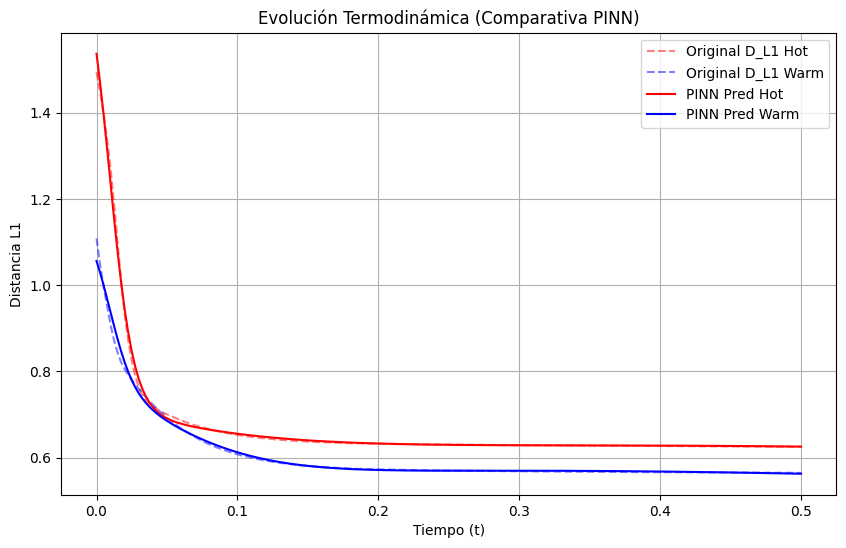

In [19]:
lstm.eval()
ode_func.eval()
pinn.eval()

with torch.no_grad():
    y_pred_ode = euler_integrate(ode_func, y[0], t)
    y_pred_pinn = pinn(t)
    
    # Para LSTM evaluamos sobre las secuencias precalculadas
    pred_lstm = lstm(X_seq)[:, -1, :]

# Métricas MSE
mse_lstm = criterion(pred_lstm, Y_seq).item()
mse_ode = criterion(y_pred_ode, y).item()
mse_pinn = criterion(y_pred_pinn, y).item()

print("=== Comparación de MSE ===")
print(f"LSTM MSE:       {mse_lstm:.6f}")
print(f"Neural ODE MSE: {mse_ode:.6f}")
print(f"PINN MSE:       {mse_pinn:.6f}")

# Gráfica
plt.figure(figsize=(10, 6))
plt.plot(t.numpy(), y[:, 0].numpy(), 'r--', alpha=0.5, label='Original D_L1 Hot')
plt.plot(t.numpy(), y[:, 1].numpy(), 'b--', alpha=0.5, label='Original D_L1 Warm')

plt.plot(t.numpy(), y_pred_pinn[:, 0].numpy(), 'r-', label='PINN Pred Hot')
plt.plot(t.numpy(), y_pred_pinn[:, 1].numpy(), 'b-', label='PINN Pred Warm')

plt.title('Evolución Termodinámica (Comparativa PINN)')
plt.xlabel('Tiempo (t)')
plt.ylabel('Distancia L1')
plt.legend()
plt.grid(True)
plt.show()

---
## PINN con Función de Pérdida Editable

In [14]:
# --- Función de Pérdida Personalizable ---
def compute_pinn_loss(model, t_data, y_data, t_phys, lambda_data=1.0, lambda_phys=0.5):
    # 1. Pérdida de Datos (MSE estándar)
    y_pred = model(t_data)
    loss_data = nn.MSELoss()(y_pred, y_data)
    
    # 2. Pérdida de Física (Restricción de la ODE)
    # Calculamos la derivada dD/dt mediante autograd
    t_phys.requires_grad_(True)
    y_phys = model(t_phys)
    
    # Derivada para la componente 'Hot'
    dD_dt_h = torch.autograd.grad(
        y_phys[:, 0].sum(), t_phys, 
        create_graph=True, retain_graph=True
    )[0]
    
    # AQUÍ PUEDES EDITAR LA RESTRICCIÓN FÍSICA:
    # Por ejemplo, si la regresión simbólica sugiere un decaimiento exponencial D' = -k*D
    # podrías probar: physics_residual = dD_dt_h + k * y_phys[:, 0]
    
    # Restricción actual: dD/dt <= 0 (proceso de relajación monótono)
    loss_phys = torch.mean(torch.max(torch.zeros_like(dD_dt_h), dD_dt_h)**2)
    
    total_loss = (lambda_data * loss_data) + (lambda_phys * loss_phys)
    return total_loss, loss_data, loss_phys

# --- Bucle de Entrenamiento Actualizado ---
pinn = PINN()
optimizer = torch.optim.Adam(pinn.parameters(), lr=0.001)

for epoch in range(1000):
    optimizer.zero_grad()
    
    # Llamada a la función de pérdida editable
    loss, l_data, l_phys = compute_pinn_loss(pinn, t, y, t_physics)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Data Loss: {l_data:.5f} | Phys Loss: {l_phys:.5f}")

Epoch 0 | Data Loss: 0.16509 | Phys Loss: 0.00305
Epoch 200 | Data Loss: 0.00935 | Phys Loss: 0.00000
Epoch 400 | Data Loss: 0.00926 | Phys Loss: 0.00000
Epoch 600 | Data Loss: 0.00912 | Phys Loss: 0.00000
Epoch 800 | Data Loss: 0.00882 | Phys Loss: 0.00000


--- 
## 5. Comparación y Evaluación del Desempeño
Analizamos el Error Cuadrático Medio (MSE) y la representación del cruce de trayectorias (efecto Mpemba).

=== Comparación de MSE ===
LSTM MSE:       0.000201
Neural ODE MSE: 0.007156
PINN MSE:       0.007445


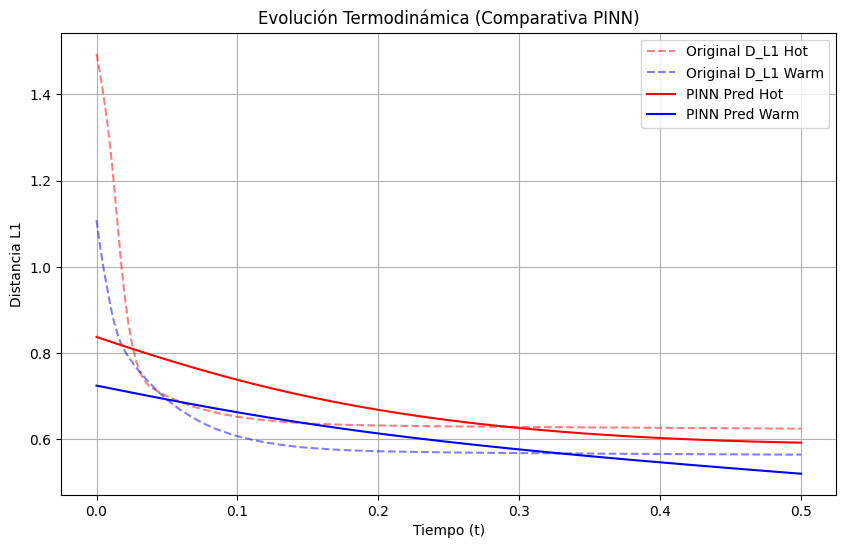

In [15]:
lstm.eval()
ode_func.eval()
pinn.eval()

with torch.no_grad():
    y_pred_ode = euler_integrate(ode_func, y[0], t)
    y_pred_pinn = pinn(t)
    
    # Para LSTM evaluamos sobre las secuencias precalculadas
    pred_lstm = lstm(X_seq)[:, -1, :]

# Métricas MSE
mse_lstm = criterion(pred_lstm, Y_seq).item()
mse_ode = criterion(y_pred_ode, y).item()
mse_pinn = criterion(y_pred_pinn, y).item()

print("=== Comparación de MSE ===")
print(f"LSTM MSE:       {mse_lstm:.6f}")
print(f"Neural ODE MSE: {mse_ode:.6f}")
print(f"PINN MSE:       {mse_pinn:.6f}")

# Gráfica
plt.figure(figsize=(10, 6))
plt.plot(t.numpy(), y[:, 0].numpy(), 'r--', alpha=0.5, label='Original D_L1 Hot')
plt.plot(t.numpy(), y[:, 1].numpy(), 'b--', alpha=0.5, label='Original D_L1 Warm')

plt.plot(t.numpy(), y_pred_pinn[:, 0].numpy(), 'r-', label='PINN Pred Hot')
plt.plot(t.numpy(), y_pred_pinn[:, 1].numpy(), 'b-', label='PINN Pred Warm')

plt.title('Evolución Termodinámica (Comparativa PINN)')
plt.xlabel('Tiempo (t)')
plt.ylabel('Distancia L1')
plt.legend()
plt.grid(True)
plt.show()

---
## Instalación y Configuración

In [16]:
# !pip install pysr
from pysr import PySRRegressor

# Definimos los datos para la regresión
# Queremos encontrar D(t) o incluso dD/dt en función de D
X_symbolic = t.numpy() 
y_symbolic = y[:, 0].numpy() # Probemos primero con la distancia 'Hot'

--- 
## Regresión simbólica

In [17]:
model_sr = PySRRegressor(
    niterations=40,  # Aumentar para mayor precisión
    binary_operators=["+", "*", "-", "/"],
    unary_operators=["exp", "log"],
    model_selection="best",
    loss="loss(prediction, target) = (prediction - target)^2"
)

model_sr.fit(X_symbolic, y_symbolic)

print("Ecuación descubierta para el sistema caliente:")
print(model_sr.sympy())

/home/sergio/Documentos/Entornos/Mpemba/lib/python3.12/site-packages/pysr/sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/home/sergio/Documentos/Entornos/Mpemba/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.802e-02  0.000e+00  y = 0.66912
4           1.410e-02  8.179e-02  y = exp(-0.16832 - x₀)
5           1.388e-02  1.541e-02  y = (x₀ * -0.4434) + 0.77997
6           3.155e-04  3.784e+00  y = exp(x₀ * -56.737) + 0.63149
8           2.930e-04  3.684e-02  y = exp(-0.044817 - (x₀ / 0.018423)) + 0.63164
17          1.048e-04  1.143e-01  y = exp(exp(-0.48071 - ((x₀ / 0.019969) / exp(exp(0.91242 ...
                                      - (x₀ / 0.0080124)))))) + -0.36784
19          1.045e-04  1.423e-03  y = exp(exp(-0.48071 - ((x₀ / 0.019969) / exp(exp((0.91242...
                                       - x₀) - (x₀ / 0.0080124)))))) + -0.36784
21          1.043e-04  7.010e-04  y = exp(exp(-0.48071 - ((x₀ / 0.019969) / exp(exp(((0.9124...
                                      2 - x₀) - x₀) - (x₀ / 0.0080124)))))) + -0.36784
22          1.03